# Evaluate the 5 hate-speech detection methods

Runs `keyword`, `tfidf`, `word2vec`, `embedding_knn`, and `transformer` (plus the equal-vote `ensemble`) from `methods.py` on any DataFrame with a `text` column and a `label` column (`1` = hateful/offensive, `0` = not), and reports accuracy/precision/recall/F1 + confusion matrices per method.

**Run Jupyter from inside the `hatespeech/` directory** (same venv as `app.py`, so `methods.py` and its models are importable):

```bash
source .venv/bin/activate
pip install jupyter ipykernel matplotlib tqdm   # if not already installed
jupyter lab
```

In [1]:
import sys
from pathlib import Path

# Make sure `methods.py` and friends are importable regardless of where
# Jupyter's cwd ends up.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "methods.py").exists() else Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from tqdm.auto import tqdm

from methods import METHOD_REGISTRY, METHOD_LABELS, run_methods

METHOD_IDS = [mid for mid, _, _ in METHOD_REGISTRY]
print("Methods available:", METHOD_IDS)

Methods available: ['keyword', 'tfidf', 'word2vec', 'embedding_knn', 'transformer']


## 1. Your data

A small hand-written demo set is below so the notebook runs out of the box.
Replace `df` with your own — just needs a `text` column and a `label` column
(`1`/`0`), e.g. `df = pd.read_csv("my_comments.csv")`.

In [2]:
demo_rows = [
    # English — hateful
    ("Get out of my country, we don't want your kind here.", 1),
    ("You're a pathetic excuse for a human being.", 1),
    ("Everyone from that group is a lying, thieving animal.", 1),
    ("Nobody would miss you if you just vanished.", 1),
    ("Shut up, you brainless waste of space.", 1),
    # English — not hateful
    ("Can we reschedule our call to Thursday afternoon?", 0),
    ("The new update fixed the bug I reported, thanks team.", 0),
    ("I'm not sure I agree, but that's a fair point.", 0),
    ("Loved the hike this weekend, the views were incredible.", 0),
    ("Could use another cup of coffee before this meeting.", 0),
    # German — hateful
    ("Verschwinde aus unserem Land, hier will dich keiner.", 1),
    ("Du bist eine erbärmliche Entschuldigung von einem Menschen.", 1),
    ("Alle aus dieser Gruppe sind lügnerische Diebe.", 1),
    ("Es würde dich niemand vermissen, wenn du einfach verschwindest.", 1),
    ("Halt die Klappe, du hirnlose Verschwendung von Platz.", 1),
    # German — not hateful
    ("Können wir unseren Anruf auf Donnerstagnachmittag verschieben?", 0),
    ("Das Update hat den gemeldeten Bug behoben, danke Team.", 0),
    ("Ich bin mir nicht sicher, aber das ist ein fairer Punkt.", 0),
    ("Die Wanderung am Wochenende war toll, tolle Aussicht.", 0),
    ("Könnte vor diesem Meeting noch einen Kaffee gebrauchen.", 0),
]
df = pd.DataFrame(demo_rows, columns=["text", "label"])
DATASET_LABEL = "the built-in demo set"
hate_qualified_mask = None  # only the hateblocker dataset below has this subset
df

,text,label
0,"Get out of my country, we don't want your kind...",1
1,You're a pathetic excuse for a human being.,1
2,"Everyone from that group is a lying, thieving ...",1
3,Nobody would miss you if you just vanished.,1
4,"Shut up, you brainless waste of space.",1
5,Can we reschedule our call to Thursday afternoon?,0
6,"The new update fixed the bug I reported, thank...",0
7,"I'm not sure I agree, but that's a fair point.",0
8,"Loved the hike this weekend, the views were in...",0
9,Could use another cup of coffee before this me...,0


### Optional: evaluate on the real held-out test set instead

The same EN (`tweet_eval` hate) + DE (GermEval 2018) split `training/train_models.py`
used to report its own accuracy — identical `train_test_split` call, so this is
the exact held-out 15% those models never trained on. Requires
`training/fetch_data.sh` to have been run first. Sampled to 200 rows by
default so the transformer/embedding methods don't take forever — drop
`.sample(...)` to run the full ~2,760-row set.

In [3]:
USE_REAL_TEST_SET = False  # flip to True after running training/fetch_data.sh

if USE_REAL_TEST_SET:
    sys.path.insert(0, str(PROJECT_ROOT / "training"))
    from sklearn.model_selection import train_test_split
    from train_models import load_data

    full_df = load_data()
    X_train, X_test, y_train, y_test = train_test_split(
        full_df["text"], full_df["label"], test_size=0.15, random_state=42, stratify=full_df["label"]
    )
    df = pd.DataFrame({"text": X_test, "label": y_test}).reset_index(drop=True)
    df = df.sample(n=200, random_state=0).reset_index(drop=True)
    DATASET_LABEL = "the real held-out test set (tweet_eval + GermEval2018)"
    hate_qualified_mask = None

df.shape

(20, 2)

### Optional: evaluate on the real hateblocker-annotated data

Loads the real German annotated comments from
`/Users/mihai/Documents/AI Factory/hatespeech` (curvemaria/patrick/rafael
workbooks) through `hateblocker.data.prepare_data()` — the exact same
loader hateblocker itself uses: same dedup, same cross-source
conflict-dropping, same 70/15/15 split (seed 42). We evaluate on its `test`
split, and `label` here means *criminally actionable* (`Klagbar_Final`),
which is a narrower target than general hatefulness — our 5 methods were
never trained to predict that, so expect lower precision here than on the
tweet_eval/GermEval set. A second, fairer comparison uses the
`hate`-qualified subset (comments that reached legal review at all), which
is closer to what these methods actually try to detect.

**Only runs if both `hateblocker-main` and the data folder are present on
your machine** — like the report section below, this isn't vendored into
this repo, and the underlying comments are not included in this repo
either (private, real annotated data). Only aggregate metrics get
committed, never row-level text.

In [4]:
USE_HATEBLOCKER_DATA = False  # flip to True to evaluate on the real annotated dataset

if USE_HATEBLOCKER_DATA:
    HATEBLOCKER_SRC = Path("/Users/mihai/Documents/AI Factory/yannik/hateblocker-main/src")
    if str(HATEBLOCKER_SRC) not in sys.path:
        sys.path.insert(0, str(HATEBLOCKER_SRC))
    from hateblocker.data import prepare_data

    HATEBLOCKER_DATA_DIR = Path("/Users/mihai/Documents/AI Factory/hatespeech")

    def _source_config(filename: str, aux_column: str) -> dict:
        return {
            "path": str(HATEBLOCKER_DATA_DIR / filename),
            "sheet_name": "Vergleich",
            "text_column": "message",
            "label_column": "Klagbar_Final",
            "positive_values": ["Ja"],
            "negative_values": ["Nein"],
            "empty_label": "negative",
            "unknown_label": "drop",
            "aux_label": {
                "column": aux_column,
                "positive_values": ["Ja"],
                "negative_values": ["Nein"],
            },
        }

    hateblocker_config = {
        "data": {
            "include": ["curvemaria", "patrick", "rafael"],
            "sources": {
                "curvemaria": _source_config("curvemaria-3000_2026-05-29.xlsx", "qual_sandra_markovic"),
                "patrick": _source_config("patrick-3000_2026-05-29.xlsx", "qual_thaddaeus"),
                "rafael": _source_config("rafael-3000_2026-05-29.xlsx", "qual_thaddaeus"),
            },
        },
        "split": {"train_size": 0.70, "validation_size": 0.15, "test_size": 0.15, "seed": 42},
    }

    prepared = prepare_data(hateblocker_config, project_root=Path("."))
    df = prepared.test[["text", "label"]].reset_index(drop=True)
    hate_qualified_mask = (prepared.test["hate"] == 1).to_numpy()
    DATASET_LABEL = "the real hateblocker test split (curvemaria/patrick/rafael, held-out 15%)"

    print(
        f"{prepared.audit['deduplicated_rows']} deduplicated comments across "
        f"{len(hateblocker_config['data']['include'])} sources "
        f"({prepared.audit['funnel_counts']}); "
        f"test split: {len(df)} rows, {int(df['label'].sum())} criminally actionable, "
        f"{int(hate_qualified_mask.sum())} hate-qualified."
    )

df.shape

(20, 2)

## 2. Run all methods

Each heavy method (embedding k-NN, transformer) downloads/loads its model on
the first call and reuses it after — the first few rows will be slower than
the rest. Set `method_ids` to a subset if you want to skip the slow ones.

In [5]:
def evaluate(data: pd.DataFrame, method_ids=None, text_col="text", label_col="label") -> pd.DataFrame:
    method_ids = method_ids or METHOD_IDS
    records = []
    for _, row in tqdm(data.iterrows(), total=len(data), desc="Analyzing"):
        result = run_methods(str(row[text_col]), method_ids)
        record = {"text": row[text_col], "ground_truth": int(row[label_col])}
        for m in result["results"]:
            record[f"{m['id']}_confidence"] = m["confidence"]
            record[f"{m['id']}_vote"] = int(m["vote"])
        record["ensemble_vote_share"] = result["ensemble"]["vote_share"]
        record["ensemble_vote"] = int(result["ensemble"]["verdict"])
        records.append(record)
    return pd.DataFrame(records)

In [6]:
method_ids = METHOD_IDS  # or e.g. ["keyword", "tfidf", "word2vec"] to skip the slow ones
results = evaluate(df, method_ids)
results

Analyzing:   0%|          | 0/20 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,text,ground_truth,keyword_confidence,keyword_vote,tfidf_confidence,tfidf_vote,word2vec_confidence,word2vec_vote,embedding_knn_confidence,embedding_knn_vote,transformer_confidence,transformer_vote,ensemble_vote_share,ensemble_vote
0,"Get out of my country, we don't want your kind...",1,0.00,0,53.45,1,76.23,1,100.00,1,99.95,1,80.0,1
1,You're a pathetic excuse for a human being.,1,59.34,1,19.62,0,62.23,1,100.00,1,0.10,0,60.0,1
2,"Everyone from that group is a lying, thieving ...",1,0.00,0,28.75,0,28.50,0,100.00,1,0.02,0,20.0,0
3,Nobody would miss you if you just vanished.,1,0.00,0,39.50,0,62.31,1,100.00,1,0.02,0,40.0,0
4,"Shut up, you brainless waste of space.",1,59.34,1,48.57,0,63.38,1,100.00,1,0.29,0,60.0,1
5,Can we reschedule our call to Thursday afternoon?,0,0.00,0,24.52,0,56.79,1,0.00,0,0.02,0,20.0,0
6,"The new update fixed the bug I reported, thank...",0,0.00,0,2.62,0,15.41,0,0.00,0,0.01,0,0.0,0
7,"I'm not sure I agree, but that's a fair point.",0,0.00,0,3.14,0,28.26,0,0.00,0,0.36,0,0.0,0
8,"Loved the hike this weekend, the views were in...",0,0.00,0,0.71,0,12.33,0,0.00,0,0.01,0,0.0,0
9,Could use another cup of coffee before this me...,0,0.00,0,3.68,0,43.05,0,0.00,0,0.02,0,0.0,0


## 3. Metrics per method

In [7]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def summarize(results_df: pd.DataFrame, method_ids) -> pd.DataFrame:
    y_true = results_df["ground_truth"]
    rows = []
    for mid in list(method_ids) + ["ensemble"]:
        y_pred = results_df[f"{mid}_vote"]
        rows.append({
            "method": METHOD_LABELS.get(mid, "Ensemble (equal vote)"),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })
    return pd.DataFrame(rows).set_index("method").round(3)

summary = summarize(results, method_ids)
summary

,accuracy,precision,recall,f1
method,,,,
Keyword Matching,0.60,1.000,0.2,0.333
TF-IDF + Logistic Regression,0.75,1.000,0.5,0.667
Word2Vec + Logistic Regression,0.85,0.889,0.8,0.842
Sentence Embedding k-NN,1.00,1.000,1.0,1.000
Fine-tuned Transformer,0.60,1.000,0.2,0.333
Ensemble (equal vote),0.85,1.000,0.7,0.824


## 4. Visualize

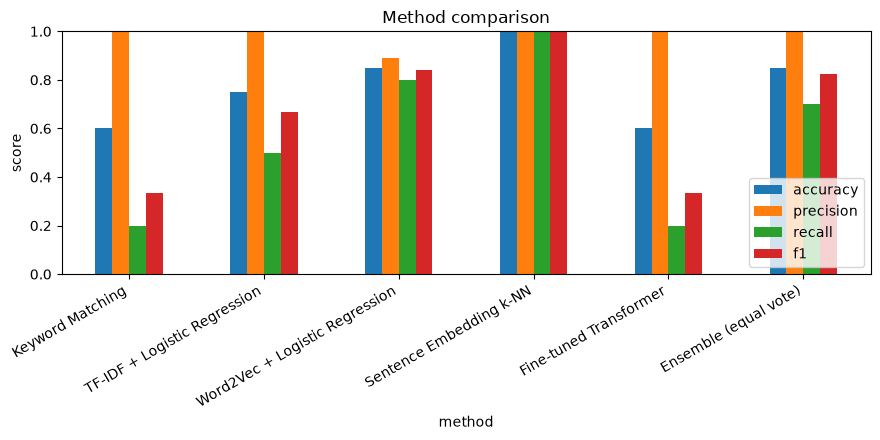

In [8]:
import matplotlib.pyplot as plt

summary[["accuracy", "precision", "recall", "f1"]].plot.bar(figsize=(9, 4.5))
plt.ylim(0, 1)
plt.ylabel("score")
plt.title("Method comparison")
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

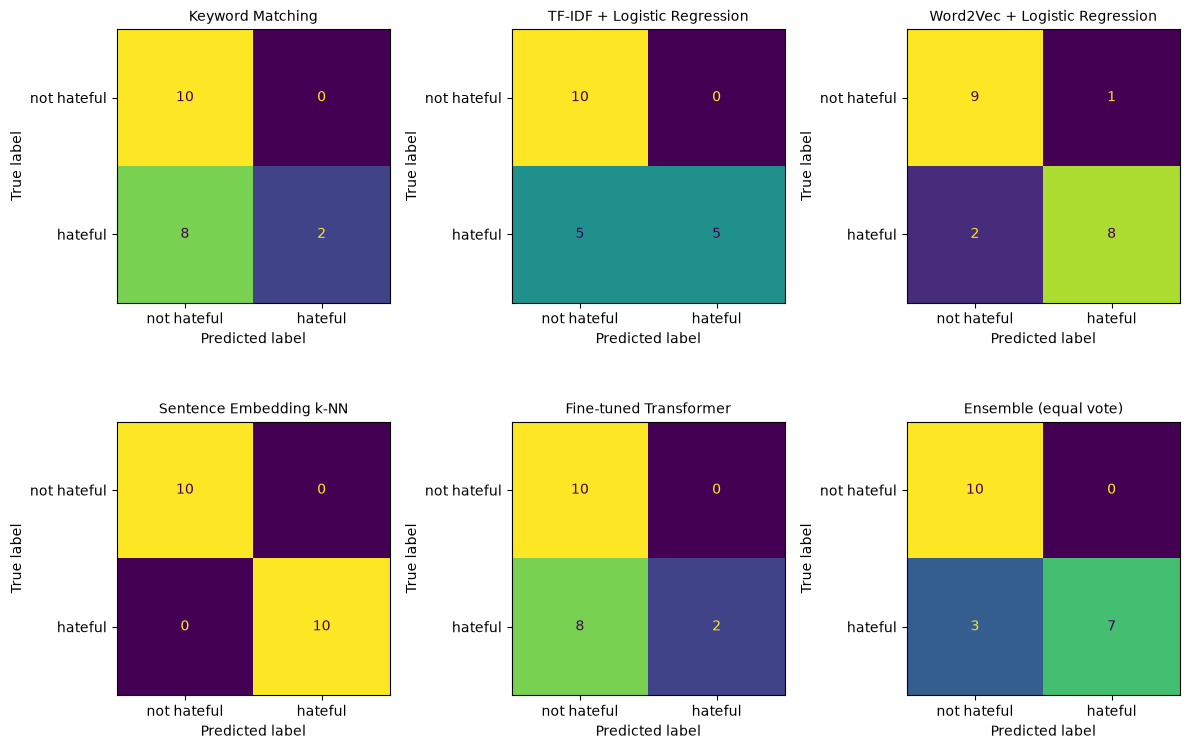

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

all_ids = list(method_ids) + ["ensemble"]
n = len(all_ids)
cols = 3
rows_n = -(-n // cols)
fig, axes = plt.subplots(rows_n, cols, figsize=(4 * cols, 4 * rows_n))
axes = axes.flatten() if n > 1 else [axes]

for ax, mid in zip(axes, all_ids):
    label = METHOD_LABELS.get(mid, "Ensemble (equal vote)")
    ConfusionMatrixDisplay.from_predictions(
        results["ground_truth"], results[f"{mid}_vote"],
        display_labels=["not hateful", "hateful"], ax=ax, colorbar=False,
    )
    ax.set_title(label, fontsize=10)

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Inspect disagreements

Rows where the ensemble got it wrong, or where methods disagreed with each
other — usually the more interesting cases.

In [10]:
wrong = results[results["ensemble_vote"] != results["ground_truth"]]
cols_to_show = ["text", "ground_truth"] + [f"{m}_vote" for m in method_ids] + ["ensemble_vote"]
wrong[cols_to_show]

,text,ground_truth,keyword_vote,tfidf_vote,word2vec_vote,embedding_knn_vote,transformer_vote,ensemble_vote
2,"Everyone from that group is a lying, thieving ...",1,0,0,0,1,0,0
3,Nobody would miss you if you just vanished.,1,0,0,1,1,0,0
11,Du bist eine erbärmliche Entschuldigung von ei...,1,0,0,1,1,0,0


## 6. Generate a Word report (reusing hateblocker's report-building code)

Reuses the actual metric computation and report-building helpers from
`/Users/mihai/Documents/AI Factory/yannik/hateblocker-main` —
`hateblocker.metrics.classification_metrics` (accuracy, balanced accuracy,
precision/recall/F1 for both classes, macro-F1, confusion matrix, average
precision, ROC-AUC) and `hateblocker.report._add_table` / `_write_figure`
(the same table and ROC/PR-curve builders their own `report.docx` uses).

This is *not* their `build_report()` entry point — that expects a finished
hateblocker training run (`config.yaml`, `data_audit.json`, a `metrics.json`
shaped around seeds/cross-validation of one model). We instead call their
lower-level, generic pieces directly on our 5-methods-vs-ensemble
comparison, which they were never written to assume anything
hateblocker-specific about.

**Only runs if hateblocker-main is present at that path on your machine** —
its code isn't vendored into this repo (separate project, imported at
runtime only).

In [11]:
HATEBLOCKER_SRC = Path("/Users/mihai/Documents/AI Factory/yannik/hateblocker-main/src")

if not HATEBLOCKER_SRC.is_dir():
    raise FileNotFoundError(
        f"{HATEBLOCKER_SRC} not found — this section only runs on a machine "
        "that has the hateblocker-main project checked out at that path."
    )

if str(HATEBLOCKER_SRC) not in sys.path:
    sys.path.insert(0, str(HATEBLOCKER_SRC))

from hateblocker.metrics import classification_metrics, subset_metrics
from hateblocker.report import _add_table, _write_figure

print("Imported classification_metrics, subset_metrics, _add_table, _write_figure from hateblocker")

Imported classification_metrics, subset_metrics, _add_table, _write_figure from hateblocker


In [12]:
import numpy as np

y_true = results["ground_truth"].to_numpy()

# hateblocker's classification_metrics wants a 0-1 "positive_scores" array for
# average_precision/roc_auc — our confidences are already 0-100 pseudo-probabilities.
method_metrics = {}
for mid in method_ids:
    y_pred = results[f"{mid}_vote"].to_numpy()
    scores = results[f"{mid}_confidence"].to_numpy() / 100.0
    method_metrics[mid] = classification_metrics(y_true, y_pred, positive_scores=scores)

# The ensemble's "score" is its vote share (0/20/40/60/80/100 for 5 methods) —
# coarse by construction, since it's an equal count of votes, not a probability.
method_metrics["ensemble"] = classification_metrics(
    y_true,
    results["ensemble_vote"].to_numpy(),
    positive_scores=results["ensemble_vote_share"].to_numpy() / 100.0,
)

# Only set when the loaded dataset carries a hate-qualification column
# (currently just the hateblocker dataset) — restricts to the harder subset
# that actually reached legal review, which is the fairer comparison for
# general-purpose hate-speech methods like these.
subset_method_metrics = None
if hate_qualified_mask is not None:
    subset_method_metrics = {}
    for mid in method_ids:
        y_pred = results[f"{mid}_vote"].to_numpy()
        scores = results[f"{mid}_confidence"].to_numpy() / 100.0
        sm = subset_metrics(y_true, y_pred, scores, hate_qualified_mask)
        if sm is not None:
            subset_method_metrics[mid] = sm
    ensemble_subset = subset_metrics(
        y_true,
        results["ensemble_vote"].to_numpy(),
        results["ensemble_vote_share"].to_numpy() / 100.0,
        hate_qualified_mask,
    )
    if ensemble_subset is not None:
        subset_method_metrics["ensemble"] = ensemble_subset

metrics_df = pd.DataFrame({
    METHOD_LABELS.get(mid, "Ensemble (equal vote)"): {
        "accuracy": m["accuracy"],
        "balanced_accuracy": m["balanced_accuracy"],
        "precision_yes": m["precision_yes"],
        "recall_yes": m["recall_yes"],
        "f1_yes": m["f1_yes"],
        "f1_macro": m["f1_macro"],
        "average_precision": m.get("average_precision"),
        "roc_auc": m.get("roc_auc"),
    }
    for mid, m in method_metrics.items()
}).T.round(3)
metrics_df

,accuracy,balanced_accuracy,precision_yes,recall_yes,f1_yes,f1_macro,average_precision,roc_auc
Keyword Matching,0.60,0.60,1.000,0.2,0.333,0.524,0.600,0.600
TF-IDF + Logistic Regression,0.75,0.75,1.000,0.5,0.667,0.733,0.981,0.980
Word2Vec + Logistic Regression,0.85,0.85,0.889,0.8,0.842,0.850,0.942,0.940
Sentence Embedding k-NN,1.00,1.00,1.000,1.0,1.000,1.000,1.000,1.000
Fine-tuned Transformer,0.60,0.60,1.000,0.2,0.333,0.524,0.753,0.700
Ensemble (equal vote),0.85,0.85,1.000,0.7,0.824,0.847,0.991,0.995


In [13]:
from docx import Document
from docx.shared import Inches

# Keep the real hateblocker report separate from the demo/tweet_eval ones —
# never overwrite one with the other.
REPORT_DIR = PROJECT_ROOT / "reports" / "hateblocker" if USE_HATEBLOCKER_DATA else PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

document = Document()
document.add_heading("Hate Speech Detector — method comparison", level=0)
document.add_paragraph(
    f"Comparison of {len(method_ids)} independent hate-speech detection methods "
    f"plus an equal-vote ensemble, evaluated on {len(results)} comments "
    f"({DATASET_LABEL}). Metrics computed with hateblocker's classification_metrics()."
)

document.add_heading("Metrics", level=1)
metric_rows = [
    ("Method", "Accuracy", "Balanced Acc.", "Precision", "Recall", "F1", "Macro F1", "Avg. Precision", "ROC-AUC")
]
for mid, m in method_metrics.items():
    label = METHOD_LABELS.get(mid, "Ensemble (equal vote)")
    metric_rows.append((
        label,
        f"{m['accuracy']:.3f}",
        f"{m['balanced_accuracy']:.3f}",
        f"{m['precision_yes']:.3f}",
        f"{m['recall_yes']:.3f}",
        f"{m['f1_yes']:.3f}",
        f"{m['f1_macro']:.3f}",
        f"{m['average_precision']:.3f}" if "average_precision" in m else "-",
        f"{m['roc_auc']:.3f}" if "roc_auc" in m else "-",
    ))
_add_table(document, metric_rows)

if subset_method_metrics:
    document.add_heading("Results on Hate-Qualified Comments Only", level=1)
    document.add_paragraph(
        "The same set restricted to comments qualified as hate speech (the "
        "subset that actually reached legal review) — the fairer comparison "
        "for general-purpose hate-speech methods that were never trained to "
        "predict criminal liability specifically."
    )
    subset_rows = [("Method", "Rows", "Accuracy", "Precision", "Recall", "F1")]
    for mid, m in subset_method_metrics.items():
        label = METHOD_LABELS.get(mid, "Ensemble (equal vote)")
        subset_rows.append((
            label, str(m["rows"]),
            f"{m['accuracy']:.3f}", f"{m['precision_yes']:.3f}",
            f"{m['recall_yes']:.3f}", f"{m['f1_yes']:.3f}",
        ))
    _add_table(document, subset_rows)

document.add_heading("Confusion matrices", level=1)
for mid, m in method_metrics.items():
    label = METHOD_LABELS.get(mid, "Ensemble (equal vote)")
    document.add_heading(label, level=2)
    cm = m["confusion_matrix"]
    _add_table(document, [
        ("", "Predicted not hateful", "Predicted hateful"),
        ("Actually not hateful", cm["tn"], cm["fp"]),
        ("Actually hateful", cm["fn"], cm["tp"]),
    ])

# _write_figure expects [(label, y_true, positive_scores), ...] — same shape
# hateblocker feeds it per-seed; here each line is a method instead of a seed.
curves = [
    (METHOD_LABELS[mid], y_true, results[f"{mid}_confidence"].to_numpy() / 100.0)
    for mid in method_ids
]
curves.append(("Ensemble (equal vote)", y_true, results["ensemble_vote_share"].to_numpy() / 100.0))

figure_path = _write_figure(REPORT_DIR, curves)
if figure_path is not None:
    document.add_heading("ROC & Precision-Recall curves", level=1)
    document.add_picture(str(figure_path), width=Inches(6.4))
    document.add_paragraph(
        "One line per method (the ensemble's curve is stepped since its score "
        "is a vote share over only 5 methods, not a continuous probability). "
        "The legend title says \"seed\" because it's hateblocker's own plotting "
        "code, reused as-is."
    )

report_path = REPORT_DIR / "evaluation_report.docx"
document.save(report_path)
print(f"Report written: {report_path}")

Report written: /Users/mihai/Documents/Products/Playground/hatespeech/reports/evaluation_report.docx
